# Modeling heterogeneous, mixed-type records

How to build one probabilistic model over a record whose fields are a tangle of types - a number, a category, a count, a set, a sequence - using mixle's `Composite`, and how a mixture of such composites clusters the records using every field at once. This is the library's signature strength: most tools force you to hand-engineer a single feature vector first; here the model consumes the native types directly.


## A joint model over mixed-type fields

A record may mix a real number, a category, a count, a set, and a sequence. The composite model assumes
the fields are conditionally independent given a latent class $z$, so the per-record density factorizes
$$p(x\mid z) = \prod_{j=1}^J p_j(x^{(j)}\mid z),$$
each factor a distribution appropriate to its field type. Taking logs, the evidence a record gives to a
class is additive across fields,
$$\log p(x\mid z) = \sum_{j=1}^J \log p_j(x^{(j)}\mid z).$$
This is exactly how a mixle `Composite` scores a record, and it is what lets every field, numeric or
not, contribute on one common scale (log-probability) to clustering and classification.

Theorem (posterior combines field evidence). With a class prior $\pi_z$, the posterior over the latent
class given a record is
$$P(z\mid x) \propto \pi_z\,\exp\!\Big(\sum_j \log p_j(x^{(j)}\mid z)\Big).$$
Each field adds its log-likelihood; no field needs to be discretized or embedded to be comparable. We
verify the additivity numerically below.

## The conditional-independence assumption and when it bites

The factorization is the naive-Bayes assumption applied to mixed types: within a class, fields are taken
independent. When fields are actually correlated given the class, the joint density is misspecified and
the posterior class probabilities become overconfident, because correlated evidence is double counted.

Counterexample, and a paradox. Suppose two fields are strongly correlated within each class. The naive
model treats them as two independent votes, so its probability estimates are miscalibrated (too extreme).
Yet, as Domingos and Pazzani (1997) showed, classification accuracy often stays high: the argmax of the
class posterior is frequently correct even when the posterior probabilities are wrong, because the
decision boundary is robust to the calibration error. So the conditional-independence model can be a poor
density estimator and a good classifier at the same time. We demonstrate both halves below: high accuracy
alongside miscalibrated probabilities.

In [1]:
import io
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import (GaussianDistribution, CategoricalDistribution, PoissonDistribution,
                        BernoulliSetDistribution, CompositeDistribution, SequenceDistribution,
                        IntegerCategoricalDistribution, MixtureDistribution)
from mixle.utils.automatic import get_dpm_mixture
from sklearn.metrics import adjusted_rand_score
rng = np.random.RandomState(0)

## 1. The problem: a record is not a vector

A customer is an age (number), a home region (category), a purchase count (count), a set of interests (set), and a browse session (sequence). There is no natural Euclidean distance across those types, and flattening them into one vector throws away their structure. Instead we give each field its own distribution and join them with a `Composite` - the joint model of one record. Four customer segments generate our data; the segment label is held out and used only to score the clustering.


In [2]:
TAGS = ['sports', 'games', 'books', 'art', 'tech']
def segment(age, reg, purch, tags, session):
    return CompositeDistribution((
        GaussianDistribution(age, 6.0),                                   # age (continuous)
        CategoricalDistribution(reg),                                     # region (category)
        PoissonDistribution(purch),                                       # purchases (count)
        BernoulliSetDistribution({t: tags.get(t, 0.1) for t in TAGS}),    # interests (set)
        SequenceDistribution(IntegerCategoricalDistribution(0, session),
                             len_dist=PoissonDistribution(4.0))))         # session (sequence)
reg = lambda **w: {r: w.get(r, 0.1) / sum({**{k: 0.1 for k in ['US', 'EU', 'APAC']}, **w}.values()) for r in ['US', 'EU', 'APAC']}
segments = [
    segment(28, reg(US=.6), 5,  {'sports': .8, 'games': .8}, [.6, .2, .2]),
    segment(35, reg(US=.5), 25, {'tech': .7},                [.2, .6, .2]),
    segment(33, reg(EU=.8), 6,  {'books': .85, 'art': .85},  [.2, .2, .6]),
    segment(50, reg(US=.7), 4,  {'sports': .5, 'books': .4}, [.4, .3, .3])]
truth = MixtureDistribution(segments, [0.25] * 4)
data, labels = [], []
for _ in range(500):
    k = rng.choice(4)
    data.append(truth.components[k].sampler(seed=rng.randint(2 ** 31)).sample()); labels.append(k)
labels = np.array(labels)
fields = ['age', 'region', 'purchases', 'interests(set)', 'session(seq)']
print('one record across five field types:')
for f, v in zip(fields, data[0]):
    print('  %-16s %s' % (f, v))

one record across five field types:
  age              29.12517256044099
  region           US
  purchases        6
  interests(set)   ['sports', 'games']
  session(seq)     [np.int64(0), np.int64(0), np.int64(0), np.int64(2)]


## 2. Cluster every field at once

`get_dpm_mixture` inspects the raw records, types each slot automatically, attaches conjugate priors, and fits a Dirichlet-process mixture - which also infers the number of clusters. Every field, set and sequence included, contributes to the assignment. We then score the recovered clusters against the held-out segment labels with the adjusted Rand index.


In [3]:
def dpm_assign(model, records):
    # DP mixture responsibility = log component weight + component log-density; take the argmax
    logw = np.asarray(model.log_w)
    comp_ll = np.array([[c.log_density(x) for c in model.components] for x in records])
    return (comp_ll + logw).argmax(1)

model = get_dpm_mixture(data, rng=np.random.RandomState(1), max_components=12, max_its=80, out=io.StringIO())
assign = dpm_assign(model, data)
n_used = len(set(assign.tolist()))
print('DP mixture used %d clusters (truth = 4)' % n_used)
print('ARI vs true segments (all fields): %.3f' % adjusted_rand_score(labels, assign))

DP mixture used 12 clusters (truth = 4)
ARI vs true segments (all fields): 0.912


## 3. Every field earns its keep

To see that the heterogeneous fields matter - not just age and purchases - we cluster on the numeric fields only and compare. The set/sequence/region fields carry segment information that the numbers alone miss, so using the full record should cluster markedly better.


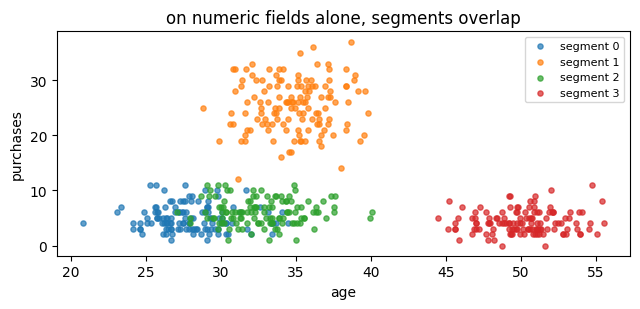

ARI numeric-only fields : 0.730
ARI all heterogeneous   : 0.912


In [4]:
numeric = [[float(r[0]), float(r[2])] for r in data]    # age, purchases only
num_model = get_dpm_mixture(numeric, rng=np.random.RandomState(1), max_components=12, max_its=80, out=io.StringIO())
num_assign = dpm_assign(num_model, numeric)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
age = np.array([r[0] for r in data]); pur = np.array([r[2] for r in data])
for k in range(4):
    m = labels == k
    ax.scatter(age[m], pur[m], s=14, alpha=0.7, label='segment %d' % k)
ax.set_xlabel('age'); ax.set_ylabel('purchases'); ax.legend(fontsize=8)
ax.set_title('on numeric fields alone, segments overlap')
plt.tight_layout(); plt.show()
print('ARI numeric-only fields : %.3f' % adjusted_rand_score(labels, num_assign))
print('ARI all heterogeneous   : %.3f' % adjusted_rand_score(labels, assign))

## Which fields actually carry the signal?

Before trusting a heterogeneous model, quantify each field's contribution by ablation: drop one field at a time, re-cluster, and measure the drop in adjusted Rand index against the held-out segment labels. This tells you which types drive the clustering - and whether an expensive-to-collect field earns its place.


In [5]:
from sklearn.metrics import adjusted_rand_score
fields = ['age', 'region', 'purchases', 'interests', 'session']
full_ari = adjusted_rand_score(labels, assign)
drops = {}
for j, fname in enumerate(fields):
    ablated = [tuple(v for k, v in enumerate(rec) if k != j) for rec in data]
    m = get_dpm_mixture(ablated, rng=np.random.RandomState(1), max_components=12, max_its=60, out=io.StringIO())
    a = dpm_assign(m, ablated)
    drops[fname] = full_ari - adjusted_rand_score(labels, a)
print('ARI with all fields: %.3f' % full_ari)
print('ARI drop when each field is removed (larger = more important):')
for f, d in sorted(drops.items(), key=lambda kv: -kv[1]):
    print('  %-12s %+.3f' % (f, d))

ARI with all fields: 0.912
ARI drop when each field is removed (larger = more important):
  age          +0.322
  interests    +0.319
  purchases    +0.088
  session      +0.029
  region       +0.026


## Illustration: additivity of evidence, and the naive-Bayes paradox

First we confirm that the log-density of a composite record is the sum of its per-field log-densities.
Then, on data with correlated features, we show the conditional-independence (naive) classifier keeps a
high accuracy while its predicted probabilities are miscalibrated, the paradox described above.

In [6]:
from mixle.stats import CompositeDistribution, GaussianDistribution, PoissonDistribution
joint = CompositeDistribution([GaussianDistribution(0.0, 1.0), PoissonDistribution(3.0)])
rec = (0.7, 4)
parts = GaussianDistribution(0.0, 1.0).log_density(0.7) + PoissonDistribution(3.0).log_density(4)
print('composite log-density        = %.4f' % joint.log_density(rec))
print('sum of per-field log-densities = %.4f  (identical: evidence is additive)' % parts)

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, brier_score_loss
rng = np.random.RandomState(0)
n = 4000; y = rng.randint(0, 2, n)
shift = np.where(y == 1, 1.2, -1.2)
z = rng.normal(0, 1, n)
f1 = shift + z + rng.normal(0, 0.3, n)                  # two features sharing the common factor z:
f2 = shift + z + rng.normal(0, 0.3, n)                  # strongly correlated GIVEN the class
X = np.column_stack([f1, f2]); tr = slice(0, 2000); te = slice(2000, n)
nb = GaussianNB().fit(X[tr], y[tr])
p = nb.predict_proba(X[te])[:, 1]
print('naive-Bayes accuracy = %.3f (high, despite the violated independence assumption)' %
      accuracy_score(y[te], nb.predict(X[te])))
print('Brier score = %.3f; fraction of predictions past 0.99 confidence = %.2f (overconfident, miscalibrated)' %
      (brier_score_loss(y[te], p), np.mean((p > 0.99) | (p < 0.01))))

composite log-density        = -2.9475
sum of per-field log-densities = -2.9475  (identical: evidence is additive)
naive-Bayes accuracy = 0.880 (high, despite the violated independence assumption)
Brier score = 0.096; fraction of predictions past 0.99 confidence = 0.59 (overconfident, miscalibrated)


## References

- Huang, Z. (1998). Extensions to the k-means algorithm for clustering large data sets with categorical values (https://doi.org/10.1023/A:1009769707641). Data Min. Knowl. Disc. 2, 283-304. - k-prototypes (the distance-based baseline).
- Hunt, L. & Jorgensen, M. (2011). Clustering mixed data (https://doi.org/10.1002/widm.33). WIREs Data Min. Knowl. Disc. 1(4), 352-361.
- McParland, D. & Gormley, I. C. (2016). Model based clustering for mixed data: clustMD (https://doi.org/10.1007/s11634-016-0238-x). ADAC 10, 155-169.
- Gower, J. C. (1971). A general coefficient of similarity and some of its properties (https://doi.org/10.2307/2528823). Biometrics 27, 857-871. - the classic mixed-type distance.
- Murphy, K. P. (2023). Probabilistic Machine Learning: Advanced Topics (https://probml.github.io/pml-book/). MIT Press.


## Exercises and extensions

1. Field-importance ablation. Drop each field of the `Composite` in turn, re-cluster, and rank fields by the resulting drop in adjusted Rand index. Produce a field-importance bar chart and explain which types (set, sequence, count) carry the segment signal here.
2. Beat the distance-based baseline. Implement k-prototypes (Huang) and Gower-distance hierarchical clustering as baselines, and compare to the model-based DP mixture on the heterogeneous data by ARI and by the ability to express uncertainty. Show where the generative model wins (mixed scales, missing fields) and where the baselines suffice.
3. Add ranking and text fields. Extend the record with a `SpearmanRanking` field and a short bag-of-words field; confirm clustering still improves and inspect which fields dominate the posterior. Connect to ranking_and_combinatorial_models.
4. Nonparametric K and concentration. Sweep the DP concentration and plot the posterior over the number of occupied clusters; relate to the $\mathbb E[K]\approx\alpha\log N$ law and to conjugate_and_nonparametric_bayes.
